In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df_old = pd.read_csv("/home/eckter/osrd/core/bench_outputs/without_fix.csv", sep=";")
df_new = pd.read_csv("/home/eckter/osrd/core/bench_outputs/dev.csv", sep=";")
print(df_old.columns, len(df_old), len(df_new))

def clean(df):
    # df["time_per_knode"] = df["time"] / df["nodes"] * 1000
    return df
df_old = clean(df_old)
df_new = clean(df_new)

df = pd.merge(df_old, df_new, on="filename", suffixes=("_old", "_new"))
df["time_diff"] = df["time_new"] - df["time_old"]
df["mb_diff"] = df["mb_new"] - df["mb_old"]

Index(['filename', 'time', 'mb', 'result_time', 'result_distance', 'error'], dtype='object') 18 18


In [3]:
def filter_columns(*names, df=df):
    columns = []
    for column in df.columns:
        if any(name in column for name in names):
            columns.append(column)
    return df[columns]

def md_describe(df):
    desc = df.describe()

    markdown_table = "| | " + " | ".join(desc.columns) + " |\n"
    markdown_table += "|---|---" + "|---".join([""] * len(desc.columns)) + "|\n"

    for stat in desc.index:
        values = desc.loc[stat]
        formatted_values = []
        for value in values:
            if isinstance(value, (int, float)):
                if np.isnan(value):
                    formatted_values.append("nan")
                else:
                    formatted_values.append(f"{value:.6f}")
            else:
                formatted_values.append(str(value))
        markdown_table += f"| {stat} | " + " | ".join(formatted_values) + " |\n"

    print(markdown_table)

In [4]:
for index, r in df.iterrows():
    old = r["result_time_old"]
    new = r["result_time_new"]
    diff = "nan"
    try:
        old = round(float(old))
        new = round(float(new))
        diff = new - old
    except Exception as e:
        pass
        
    if old != new:
        if type(diff) is str or abs(diff) > 2:
            print(f"DIFFER: {old=}, {new=}, {diff=}, {r['filename']}")

In [5]:
df.describe()

,time_old,mb_old,error_old,time_new,mb_new,error_new,time_diff,mb_diff
count,18.000000,18.000000,0.0,18.000000,18.000000,0.0,18.000000,18.000000
mean,15.538333,2929.277778,NaN,15.595667,2917.277778,NaN,0.057333,-12.000000
std,18.136879,1942.561129,NaN,18.452941,1665.829234,NaN,0.709698,940.465091
min,0.191000,1530.000000,NaN,0.188000,1533.000000,NaN,-0.826000,-1827.000000
25%,0.584750,1799.000000,NaN,0.555500,1808.500000,NaN,-0.305000,-40.500000
50%,5.379000,2167.500000,NaN,4.961500,2219.000000,NaN,-0.014000,3.000000
75%,30.518500,3329.250000,NaN,30.387250,3562.750000,NaN,-0.004500,62.000000
max,54.828000,9210.000000,NaN,57.122000,7383.000000,NaN,2.294000,2515.000000


In [6]:
df

,filename,time_old,mb_old,result_time_old,result_distance_old,error_old,time_new,mb_new,result_time_new,result_distance_new,error_new,time_diff,mb_diff
0,bench_payloads/stdcm-11-12-15:46:31:978.json,43.180,3794,no_path_found,no_path_found,NaN,42.589,3636,no_path_found,no_path_found,NaN,-0.591,-158
1,bench_payloads/stdcm-11-12-15:47:37:588.json,32.380,1894,no_path_found,no_path_found,NaN,31.959,1858,no_path_found,no_path_found,NaN,-0.421,-36
2,bench_payloads/stdcm-11-27-11:12:53:472.json,0.584,1841,7450.94537,190782.0,NaN,0.549,1843,7450.94537,190782.0,NaN,-0.035,2
3,bench_payloads/stdcm-11-12-15:41:09:730.json,3.305,3264,no_path_found,no_path_found,NaN,3.296,3343,no_path_found,no_path_found,NaN,-0.009,79
4,bench_payloads/stdcm-11-12-15:41:24:229.json,9.436,3614,18231.698545,500158.0,NaN,9.051,2087,18231.602104,499100.0,NaN,-0.385,-1527
5,bench_payloads/stdcm-11-27-11:13:16:415.json,0.587,2242,12105.666694,295935.0,NaN,0.575,2245,12105.666694,295935.0,NaN,-0.012,3
6,bench_payloads/stdcm-11-27-11:11:00:341.json,0.264,1602,5850.23285,191961.0,NaN,0.245,1605,5850.23285,191961.0,NaN,-0.019,3
7,bench_payloads/stdcm-11-12-15:48:27:804.json,34.667,3351,no_path_found,no_path_found,NaN,34.949,5866,no_path_found,no_path_found,NaN,0.282,2515
8,bench_payloads/stdcm-11-27-11:14:07:581.json,2.231,1715,24180.26976,489334.0,NaN,2.166,1673,24180.26976,489334.0,NaN,-0.065,-42
9,bench_payloads/stdcm-11-27-11:12:41:076.json,0.191,1530,7452.70996,190782.0,NaN,0.188,1533,7452.70996,190782.0,NaN,-0.003,3


In [7]:
filter_columns("time").describe()

,time_old,time_new,time_diff
count,18.000000,18.000000,18.000000
mean,15.538333,15.595667,0.057333
std,18.136879,18.452941,0.709698
min,0.191000,0.188000,-0.826000
25%,0.584750,0.555500,-0.305000
50%,5.379000,4.961500,-0.014000
75%,30.518500,30.387250,-0.004500
max,54.828000,57.122000,2.294000


In [18]:
filter_columns("mb").describe()

,mb_old,mb_new,mb_diff
count,11.000000,11.000000,11.000000
mean,3455.454545,3660.454545,205.000000
std,1511.688815,1634.764837,1085.485698
min,1635.000000,1650.000000,-1130.000000
25%,2568.000000,2561.000000,-382.500000
50%,3135.000000,3257.000000,14.000000
75%,3726.000000,4857.000000,75.000000
max,6399.000000,6444.000000,2826.000000


In [8]:
larger = df[df["time_old"] > 2]
larger.describe()

,time_old,mb_old,error_old,time_new,mb_new,error_new,time_diff,mb_diff
count,10.000000,10.000000,0.0,10.000000,10.000000,0.0,10.000000,10.000000
mean,24.951500,3637.500000,NaN,25.954800,3371.200000,NaN,1.003300,-266.300000
std,13.851915,1460.843383,NaN,14.341975,899.932318,NaN,2.185789,1486.052343
min,3.154000,1910.000000,NaN,2.570000,1775.000000,NaN,-1.122000,-2083.000000
25%,13.459500,2888.250000,NaN,13.672250,2783.250000,NaN,-0.527000,-1414.500000
50%,28.849500,3245.000000,NaN,31.496500,3277.500000,NaN,0.117500,-408.500000
75%,33.653750,3741.000000,NaN,37.250750,4158.250000,NaN,2.510000,250.250000
max,41.854000,6399.000000,NaN,40.732000,4662.000000,NaN,4.799000,2370.000000


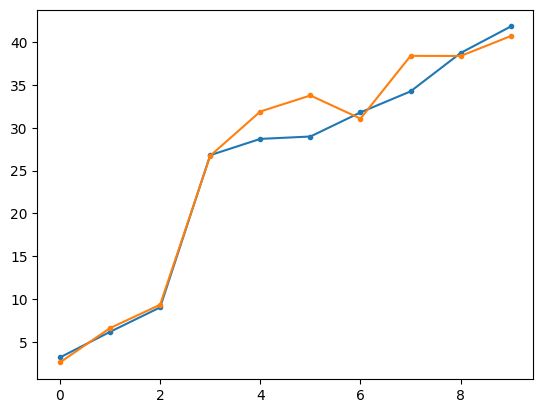

In [9]:
for c in ["time_old", "time_new"]:
    plt.plot(range(len(larger)), larger.sort_values("time_old")[c], label=c, marker='.')


In [10]:
df[df["time_old"] > 10].describe()

,time_old,mb_old,error_old,time_new,mb_new,error_new,time_diff,mb_diff
count,7.000000,7.000000,0.0,7.000000,7.000000,0.0,7.000000,7.000000
mean,33.028714,3623.285714,NaN,34.439000,3209.000000,NaN,1.410286,-414.285714
std,5.589146,1325.507666,NaN,4.976863,1005.481311,NaN,2.533639,1502.562668
min,26.808000,2292.000000,NaN,26.735000,1775.000000,NaN,-1.122000,-2083.000000
25%,28.849500,2932.500000,NaN,31.496500,2640.000000,NaN,-0.542500,-1335.500000
50%,31.811000,3355.000000,NaN,33.788000,3108.000000,NaN,-0.073000,-648.000000
75%,36.514500,3726.000000,NaN,38.412500,3819.000000,NaN,3.676500,66.000000
max,41.854000,6399.000000,NaN,40.732000,4662.000000,NaN,4.799000,2370.000000
